# YOLOv8n Fine-Tuning on LISA Traffic Signs

This notebook walks through every step of fine-tuning a YOLOv8n model on the LISA traffic-sign dataset.

**Steps**
1. Install dependencies
2. Set configuration
3. Prepare the LISA dataset (CSV → YOLO format)
4. Inspect the dataset
5. Load the base model
6. Train
7. Review metrics
8. Save the best model to `trained_models/`
9. Run a quick validation inference

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
from pathlib import Path

LISA_ZIP  = Path('/content/drive/MyDrive/OmniAI/Lisa.zip')
LISA_ROOT = Path('/content/lisa_data')

if LISA_ROOT.exists() and any(LISA_ROOT.iterdir()):
    print('Already extracted  — skipping')
else:
    print('Extracting Lisa.zip to local VM...')
    LISA_ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(LISA_ZIP, 'r') as z:
        z.extractall(LISA_ROOT)
    print('Extracted ')

# Verify structure
csv_files = list(LISA_ROOT.rglob('frameAnnotationsBOX.csv'))
print(f'frameAnnotationsBOX.csv files: {len(csv_files)}')
print('\nFirst 3:')
for f in csv_files[:3]:
    print(f'  {f}')

Extracting Lisa.zip to local VM...
Extracted 
frameAnnotationsBOX.csv files: 24

First 3:
  /content/lisa_data/sample-nightClip1/sample-nightClip1/frameAnnotationsBOX.csv
  /content/lisa_data/sample-dayClip6/sample-dayClip6/frameAnnotationsBOX.csv
  /content/lisa_data/Annotations/Annotations/daySequence1/frameAnnotationsBOX.csv


## Step 0 — Google Colab Setup
Run this cell **only on Colab**. Skip it if running locally.

In [ ]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ

if IN_COLAB:
    # ── Mount Google Drive ────────────────────────────────────────────────────
    from google.colab import drive
    drive.mount('/content/drive')

    # ── Install deps ──────────────────────────────────────────────────────────
    os.system('pip install ultralytics opencv-python-headless -q')

    # ── GPU check ─────────────────────────────────────────────────────────────
    import torch
    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0
    print(f'GPU : {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

    if not torch.cuda.is_available():
        raise RuntimeError('No GPU detected. Runtime → Change runtime type → A100 or V100 → Save & Reconnect')

    # ── Batch size based on VRAM ──────────────────────────────────────────────
    # A100 = ~40GB, V100 = ~16GB, T4 = ~15GB
    if vram_gb >= 35:       # A100
        _batch, _workers = 64, 8
    elif vram_gb >= 14:     # V100 / T4
        _batch, _workers = 32, 4
    else:
        _batch, _workers = 16, 2



    # ── Path overrides ────────────────────────────────────────────────────────
    DRIVE_PROJECT = '/content/drive/MyDrive/OmniAI/training'

    import pathlib
    REPO_ROOT  = pathlib.Path(DRIVE_PROJECT)
    LISA_ROOT  = pathlib.Path('/content/lisa_data')
    YOLO_DATA  = pathlib.Path('/content/lisa_yolo')
    BASE_MODEL = pathlib.Path('/content/drive/MyDrive/OmniAI/training_models/yolov8n_lisa_best.pt')
    OUT_DIR    = pathlib.Path('/content/drive/MyDrive/OmniAI/training_models')

    # ── Training params ───────────────────────────────────────────────────────
    EPOCHS   = 50
    IMG_SIZE = 640
    BATCH    = _batch
    WORKERS  = _workers
    LR0      = 0.001
    PATIENCE = 20
    AUGMENT  = True
    FREEZE   = 0
    DEVICE   = '0'

    RUN_PROJECT = '/content/runs/train'
    RUN_NAME    = 'lisa_yolov8n_v1.1'
    VAL_SPLIT   = 0.15
    SEED        = 42

    sys.path.insert(0, str(REPO_ROOT / 'training'))

    print(f'REPO_ROOT  : {REPO_ROOT}  exists={REPO_ROOT.exists()}')
    print(f'LISA_ROOT  : {LISA_ROOT}  exists={LISA_ROOT.exists()}')
    print(f'BASE_MODEL : {BASE_MODEL}  exists={BASE_MODEL.exists()}')
    print(f'DEVICE     : {DEVICE}  |  BATCH={BATCH}  WORKERS={WORKERS}  EPOCHS={EPOCHS}')
else:
    print('Not on Colab — skipping. Proceed to Step 2.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU : Tesla T4  |  VRAM: 15.6 GB
REPO_ROOT  : /content/drive/MyDrive/OmniAI/training  exists=True
LISA_ROOT  : /content/lisa_data  exists=True
BASE_MODEL : /content/drive/MyDrive/OmniAI/training_models/yolov8n_lisa_best.pt  exists=True
DEVICE     : 0  |  BATCH=32  WORKERS=4  EPOCHS=50


In [ ]:
# ── GPU Verification (Colab Pro) ─────────────────────────────────────────────
import torch

print('torch version  :', torch.__version__)
print('CUDA available :', torch.cuda.is_available())

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU name       : {props.name}')
    print(f'VRAM           : {props.total_memory / 1e9:.1f} GB')
    print(f'CUDA version   : {torch.version.cuda}')
    # Quick tensor test
    x = torch.zeros(1).cuda()
    print(f'Tensor device  : {x.device}')
    print('\nGPU is ready.')
else:
    print('\nNo GPU — go to: Runtime → Change runtime type → A100 → Save')


torch version  : 2.10.0+cu128
CUDA available : True
GPU name       : Tesla T4
VRAM           : 15.6 GB
CUDA version   : 12.8
Tensor device  : cuda:0

GPU is ready.


## Step 1 — Install Dependencies

In [ ]:
# Run once; restart kernel if packages were freshly installed
%pip install ultralytics opencv-python-headless --quiet

## Step 2 — Configuration

Edit the variables below before running the rest of the notebook.

In [ ]:
import sys, os
import torch
from pathlib import Path

# On Colab, Step 0 already set all variables — skip this cell
IN_COLAB = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ
if IN_COLAB:
    print('Colab detected — Step 0 config is active. Skipping Step 2.')
else:
    # ── Paths ────────────────────────────────────────────────────────────

    REPO_ROOT  = pathlib.Path(DRIVE_PROJECT)
    LISA_ROOT  = pathlib.Path('/content/lisa_data')
    YOLO_DATA  = pathlib.Path('/content/lisa_yolo')
    BASE_MODEL = pathlib.Path('/content/drive/MyDrive/OmniAI/training_models/yolov8n_lisa_best.pt')
    OUT_DIR    = pathlib.Path('/content/drive/MyDrive/OmniAI/training_models')

    # ── Device — validate before trusting ────────────────────────────────
    def _detect_device() -> str:
        if torch.cuda.is_available():
            try:
                torch.zeros(1).cuda()
                return '0'
            except Exception:
                pass
        if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
            try:
                torch.zeros(1).to('mps')
                return 'mps'
            except Exception:
                pass
        return 'cpu'

    DEVICE = _detect_device()

    # ── Training hyper-parameters ─────────────────────────────────────────
    EPOCHS   = 50
    IMG_SIZE = 640
    BATCH    = 8  if DEVICE == 'cpu' else 16
    WORKERS  = 0  if DEVICE == 'cpu' else 4
    LR0      = 0.001
    PATIENCE = 15
    AUGMENT  = True
    FREEZE   = 0

    RUN_PROJECT = str(REPO_ROOT / 'runs' / 'train')
    RUN_NAME    = 'lisa_yolov8n'
    VAL_SPLIT   = 0.15
    SEED        = 42

    sys.path.insert(0, str(REPO_ROOT / 'training'))

    print('REPO_ROOT :', REPO_ROOT)
    print('LISA_ROOT :', LISA_ROOT, '→ exists:', LISA_ROOT.exists())
    print('BASE_MODEL:', BASE_MODEL, '→ exists:', BASE_MODEL.exists())
    print(f'Device    : {DEVICE}')


Colab detected — Step 0 config is active. Skipping Step 2.


## Step 3 — Prepare the LISA Dataset

Reads all `frameAnnotationsBOX.csv` files, converts bounding boxes to normalised
YOLO format, splits into train / val, and writes `dataset.yaml`.

> **Skip this cell** if you have already run it once and `lisa_yolo/` exists.

In [ ]:
import sys
from pathlib import Path

# LISA already extracted to /content/lisa_data
LISA_ROOT = Path('/content/lisa_data')

# Add training dir to path for imports
sys.path.insert(0, str(REPO_ROOT))

from prepare_lisa import prepare

if YOLO_DATA.exists() and any(YOLO_DATA.iterdir()):
    print('LISA already prepared  — skipping')
    yaml_path = YOLO_DATA / 'dataset.yaml'
else:
    print('Preparing LISA dataset...')
    yaml_path = prepare(
        lisa_root  = str(LISA_ROOT),
        out_root   = str(YOLO_DATA),
        val_split  = VAL_SPLIT,
        seed       = SEED,
        max_images = None,    # ← use ALL images
    )

print(f'\ndataset.yaml: {yaml_path}')

Preparing LISA dataset...

dataset.yaml: /content/lisa_yolo/dataset.yaml


## Step 4 — Inspect the Dataset

In [ ]:
import sys
from pathlib import Path
from collections import Counter

# Ensure training modules are importable (Colab + local)
training_dir = REPO_ROOT / 'training'
if str(training_dir) not in sys.path:
    sys.path.insert(0, str(training_dir))

from lisa_classes import CLASS_NAMES

# ── File counts ──────────────────────────────────────────────────────────
train_imgs = list((YOLO_DATA / 'images' / 'train').glob('*.jpg'))
val_imgs   = list((YOLO_DATA / 'images' / 'val').glob('*.jpg'))
print(f'Train images : {len(train_imgs)}')
print(f'Val   images : {len(val_imgs)}')

# ── Class distribution ───────────────────────────────────────────────────
counter: Counter = Counter()
for split in ('train', 'val'):
    for lbl_file in (YOLO_DATA / 'labels' / split).glob('*.txt'):
        for line in lbl_file.read_text().splitlines():
            if line.strip():
                counter[int(line.split()[0])] += 1

print('\nAnnotation counts per class:')
for idx, name in enumerate(CLASS_NAMES):
    print(f'  {idx:2d}  {name:<20s} {counter.get(idx, 0):>6d}')


Train images : 30826
Val   images : 5439

Annotation counts per class:
   0  go                    46723
   1  goForward               205
   2  goLeft                 2476
   3  stop                  44318
   4  stopLeft              12734
   5  warning                2669
   6  warningLeft             350


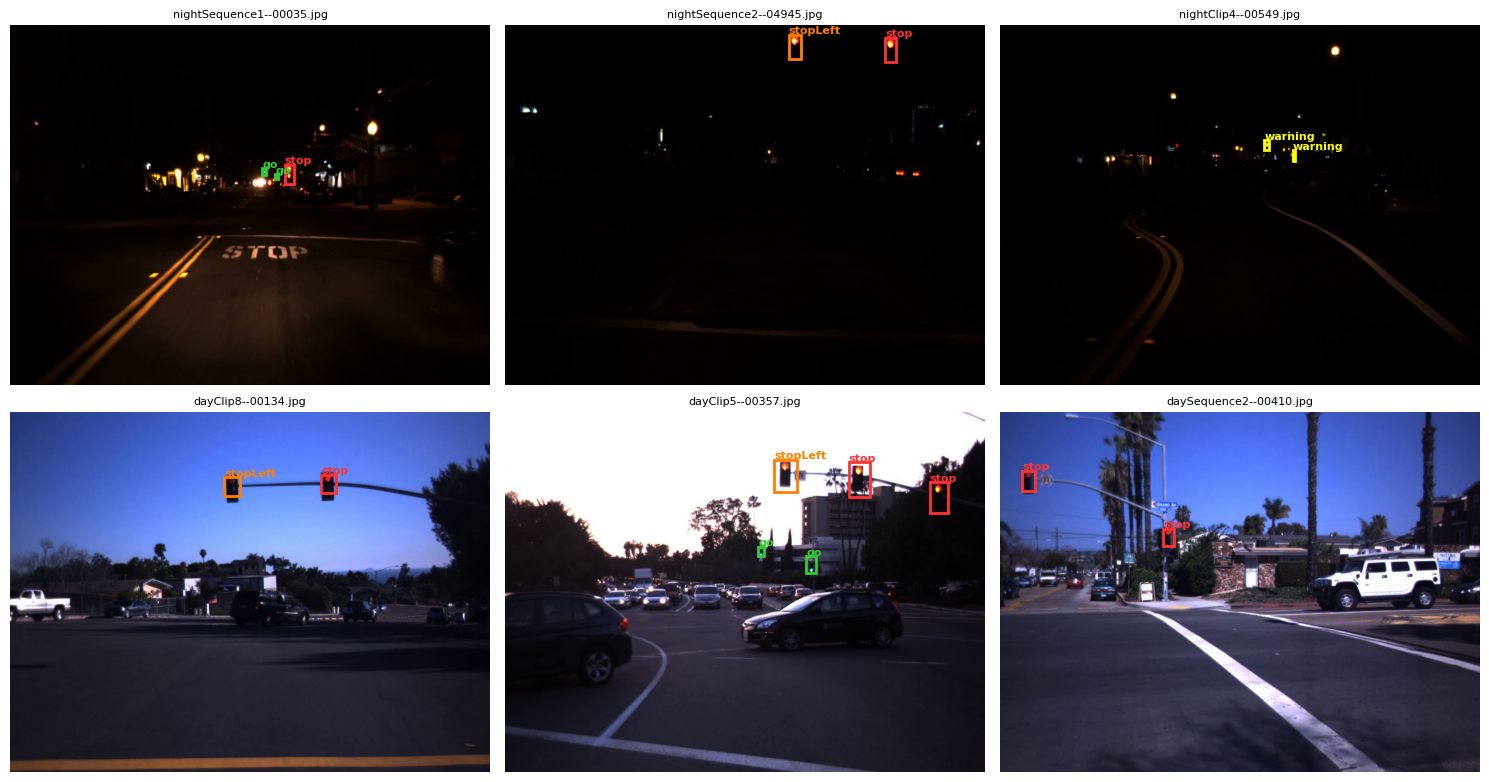

In [ ]:
# ── Visualise a random training sample ───────────────────────────────────────
import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

COLORS = [
    (0.2, 0.8, 0.2),  # go         – green
    (0.0, 0.6, 1.0),  # goForward  – blue
    (0.0, 1.0, 1.0),  # goLeft     – cyan
    (1.0, 0.2, 0.2),  # stop       – red
    (1.0, 0.5, 0.0),  # stopLeft   – orange
    (1.0, 1.0, 0.0),  # warning    – yellow
    (0.8, 0.0, 0.8),  # warningLeft– purple
]

random.seed(0)
sample_imgs = random.sample(train_imgs, min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, img_path in zip(axes.flat, sample_imgs):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)

    lbl_path = YOLO_DATA / "labels" / "train" / (img_path.stem + ".txt")
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            cls_idx = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:])
            x1 = (cx - bw / 2) * w
            y1 = (cy - bh / 2) * h
            color = COLORS[cls_idx % len(COLORS)]
            rect = patches.Rectangle(
                (x1, y1), bw * w, bh * h,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(
                x1, y1 - 4, CLASS_NAMES[cls_idx],
                color=color, fontsize=8, fontweight="bold"
            )

    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

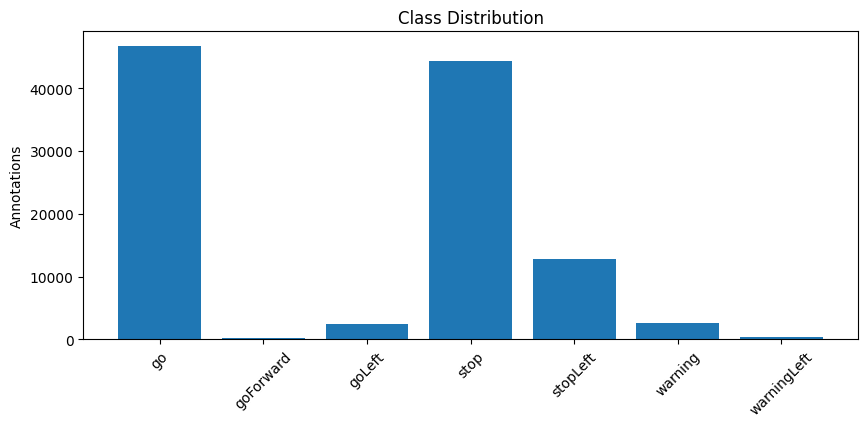

In [ ]:
import matplotlib.pyplot as plt

classes = [
"go","goForward","goLeft",
"stop","stopLeft","warning","warningLeft"
]

counts = [46723,205,2476,44318,12734,2669,350]

plt.figure(figsize=(10,4))
plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.ylabel("Annotations")
plt.show()

Total images checked: 30826
Min objects in an image: 1
Max objects in an image: 9


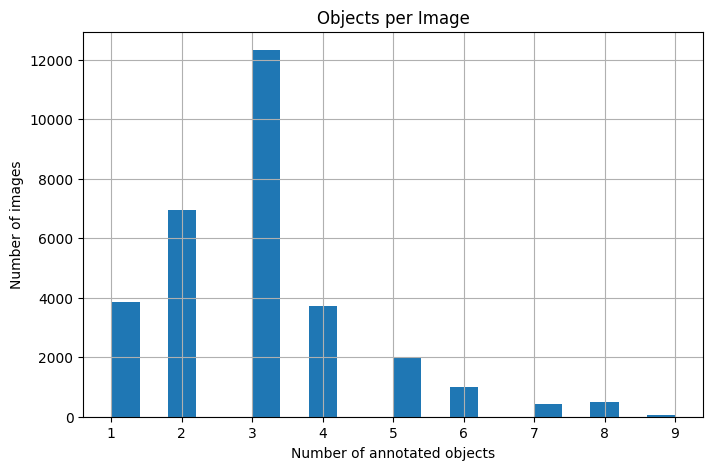

In [ ]:
# Count how many annotated objects appear in each training image
# and plot a histogram of objects per image

from pathlib import Path
import matplotlib.pyplot as plt

label_dir = YOLO_DATA / "labels" / "train"

objects_per_image = []

for label_file in label_dir.glob("*.txt"):
    with open(label_file, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]
        objects_per_image.append(len(lines))

print("Total images checked:", len(objects_per_image))
print("Min objects in an image:", min(objects_per_image))
print("Max objects in an image:", max(objects_per_image))

plt.figure(figsize=(8, 5))
plt.hist(objects_per_image, bins=20)
plt.title("Objects per Image")
plt.xlabel("Number of annotated objects")
plt.ylabel("Number of images")
plt.grid(True)
plt.show()


In [ ]:
# Determine which classes are rare based on annotation counts
# Classes below a chosen threshold will be treated as rare

class_counts = {
    "go": 46723,
    "goForward": 205,
    "goLeft": 2476,
    "stop": 44318,
    "stopLeft": 12734,
    "warning": 2669,
    "warningLeft": 350
}

threshold = 3000

rare_classes = [cls for cls, count in class_counts.items() if count < threshold]

print("Rare classes:", rare_classes)


Rare classes: ['goForward', 'goLeft', 'warning', 'warningLeft']


In [ ]:
# Count train images and labels in the prepared dataset
train_images = list((YOLO_DATA / "images" / "train").glob("*"))
train_labels = list((YOLO_DATA / "labels" / "train").glob("*.txt"))

print("Train images:", len(train_images))
print("Train labels:", len(train_labels))

Train images: 30826
Train labels: 30826


In [ ]:
# Count how many images contain each class
# This is often more useful than raw annotation totals for imbalance checks

from collections import Counter

label_dir = YOLO_DATA / "labels" / "train"

images_per_class = Counter()
annotations_per_class = Counter()

for label_file in label_dir.glob("*.txt"):
    classes_in_image = set()

    with open(label_file, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue

            class_id = int(parts[0])
            annotations_per_class[class_id] += 1
            classes_in_image.add(class_id)

    for class_id in classes_in_image:
        images_per_class[class_id] += 1

print("Images containing each class:")
for class_id, count in sorted(images_per_class.items()):
    print(class_id, count)

print("\nAnnotation counts per class:")
for class_id, count in sorted(annotations_per_class.items()):
    print(class_id, count)

Images containing each class:
0 15833
1 131
2 1590
3 15821
4 8818
5 933
6 198

Annotation counts per class:
0 39650
1 166
2 2115
3 37749
4 10817
5 2269
6 306


In [ ]:
# Oversample rare-class images safely

# Import required modules
import shutil
from pathlib import Path

# Point to the prepared YOLO dataset folders
label_dir = YOLO_DATA / "labels" / "train"
image_dir = YOLO_DATA / "images" / "train"

print("Label dir:", label_dir)
print("Image dir:", image_dir)

# Define rare class IDs based on your analysis
rare_classes = [1, 6]   # goForward, warningLeft

oversample_factor = 3   # safer than 4 for large datasets

for label_file in label_dir.glob("*.txt"):

    # Skip files that are already augmented
    if "_aug" in label_file.stem:
        continue

    # Read classes present in this image
    with open(label_file) as f:
        classes = [int(line.split()[0]) for line in f.readlines()]

    # If image contains rare classes
    if any(c in rare_classes for c in classes):

        # Find corresponding image file
        img_candidates = list(image_dir.glob(label_file.stem + ".*"))
        if not img_candidates:
            continue

        img_file = img_candidates[0]

        # Create duplicated copies
        for i in range(oversample_factor):

            new_img = image_dir / f"{label_file.stem}_aug{i}{img_file.suffix}"
            new_lbl = label_dir / f"{label_file.stem}_aug{i}.txt"

            if not new_img.exists():
                shutil.copy(img_file, new_img)
                shutil.copy(label_file, new_lbl)

Label dir: /content/lisa_yolo/labels/train
Image dir: /content/lisa_yolo/images/train


In [ ]:
# Count how many images contain each class after oversampling

from collections import Counter

label_dir = YOLO_DATA / "labels" / "train"

images_per_class = Counter()
annotations_per_class = Counter()

for label_file in label_dir.glob("*.txt"):
    classes_in_image = set()

    with open(label_file, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue

            class_id = int(parts[0])
            annotations_per_class[class_id] += 1
            classes_in_image.add(class_id)

    for class_id in classes_in_image:
        images_per_class[class_id] += 1

print("Images containing each class:")
for class_id, count in sorted(images_per_class.items()):
    print(class_id, count)

print("\nAnnotation counts per class:")
for class_id, count in sorted(annotations_per_class.items()):
    print(class_id, count)

Images containing each class:
0 16262
1 524
2 1758
3 15821
4 8866
5 1215
6 792

Annotation counts per class:
0 40427
1 664
2 2283
3 37749
4 10865
5 3115
6 1224


## Step 5 — Load the Base Model

In [ ]:
from ultralytics import YOLO

model = YOLO(str(BASE_MODEL))
print("Model loaded:", BASE_MODEL.name)
print("Parameters  :", sum(p.numel() for p in model.model.parameters()), "total")

Model loaded: yolov8n_lisa_best.pt
Parameters  : 3012213 total


## Step 6 — Train

Progress bars and per-epoch metrics will stream directly into this cell's output.
Training writes checkpoints to `runs/train/lisa_yolov8n/weights/`.

In [ ]:
from ultralytics import YOLO

# yaml_path may not be set if Step 3 was skipped — resolve from config
yaml_path = YOLO_DATA / 'dataset.yaml'
if not yaml_path.exists():
    raise FileNotFoundError(
        f'Dataset YAML not found: {yaml_path}\nRun Step 3 first.'
    )

model = YOLO(str(BASE_MODEL))

train_kwargs = dict(
    data       = str(yaml_path.resolve()),
    epochs     = EPOCHS,
    imgsz      = IMG_SIZE,
    batch      = BATCH,
    workers    = WORKERS,
    device     = DEVICE,
    lr0        = LR0,
    patience   = PATIENCE,
    project    = RUN_PROJECT,
    name       = RUN_NAME,
    exist_ok   = True,
    # Augmentation parameters
    mosaic     = 1.0 if AUGMENT else 0.0,
    mixup      = 0.1 if AUGMENT else 0.0,
    hsv_h      = 0.015 if AUGMENT else 0.0,
    hsv_s      = 0.7 if AUGMENT else 0.0,
    hsv_v      = 0.4 if AUGMENT else 0.0,
    degrees    = 10 if AUGMENT else 0.0,
    translate  = 0.1 if AUGMENT else 0.0,
    scale      = 0.5 if AUGMENT else 0.0,
    fliplr     = 0.5 if AUGMENT else 0.0,

    copy_paste = 0.0,   # disabled — causes shape mismatch on LISA
    freeze     = FREEZE if FREEZE > 0 else None,
    verbose    = True,
    save       = True,
    save_period= -1,
    plots      = False,
)

print('Training config:')
for k, v in train_kwargs.items():
    print(f'  {k:<12}: {v}')

results = model.train(**train_kwargs)
print('\nTraining complete.')


Training config:
  data        : /content/lisa_yolo/dataset.yaml
  epochs      : 50
  imgsz       : 640
  batch       : 64
  workers     : 8
  device      : 0
  lr0         : 0.001
  patience    : 20
  project     : /content/runs/train
  name        : lisa_yolov8n_v1.1
  exist_ok    : True
  mosaic      : 1.0
  mixup       : 0.1
  hsv_h       : 0.015
  hsv_s       : 0.7
  hsv_v       : 0.4
  degrees     : 10
  translate   : 0.1
  scale       : 0.5
  fliplr      : 0.5
  copy_paste  : 0.0
  freeze      : None
  verbose     : True
  save        : True
  save_period : -1
  plots       : False
New https://pypi.org/project/ultralytics/8.4.22 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, con

## Step 7 — Review Metrics

In [ ]:
# ── Scalar summary ───────────────────────────────────────────────────────────
metrics = results.results_dict
print("Final validation metrics:")
for key in (
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)",
    "metrics/precision(B)",
    "metrics/recall(B)",
):
    print(f"  {key:<30s}: {metrics.get(key, float('nan')):.4f}")

Final validation metrics:
  metrics/mAP50(B)              : 0.9519
  metrics/mAP50-95(B)           : 0.6469
  metrics/precision(B)          : 0.9283
  metrics/recall(B)             : 0.9221


/tmp/ipykernel_860/150780517.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


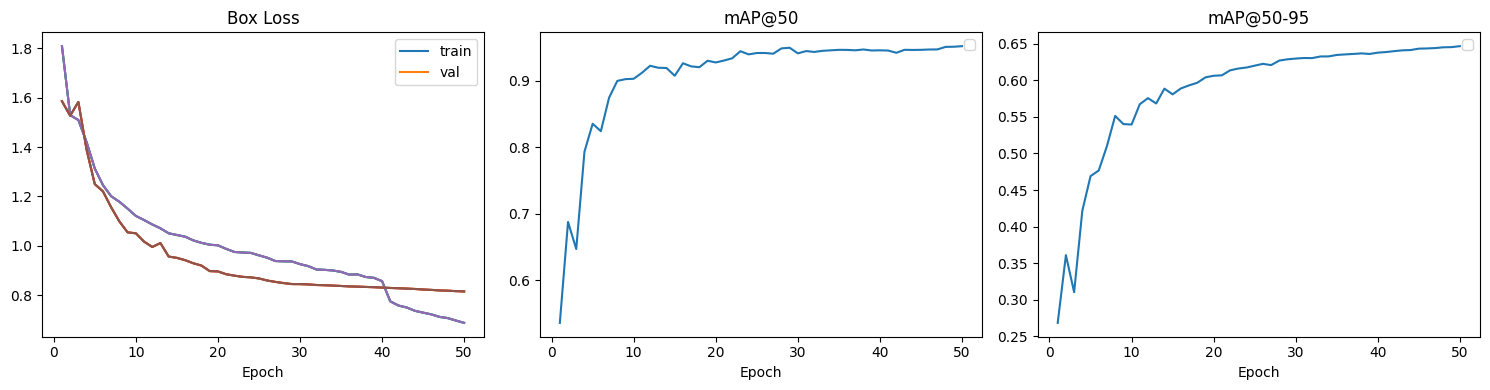

In [ ]:
# ── Training curves (loss + mAP) ─────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

results_csv = Path(RUN_PROJECT) / RUN_NAME / "results.csv"

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Box loss
    for col, ax, title in [
        ("train/box_loss",        axes[0], "Box Loss"),
        ("metrics/mAP50(B)",      axes[1], "mAP@50"),
        ("metrics/mAP50-95(B)",   axes[2], "mAP@50-95"),
    ]:
        if col in df.columns:
            axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
            if "val/box_loss" in df.columns:
                axes[0].plot(df["epoch"], df["val/box_loss"], label="val")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()

    if "metrics/mAP50(B)" in df.columns:
        axes[1].plot(df["epoch"], df["metrics/mAP50(B)"])
    if "metrics/mAP50-95(B)" in df.columns:
        axes[2].plot(df["epoch"], df["metrics/mAP50-95(B)"])

    plt.tight_layout()
    plt.show()
else:
    print("results.csv not found – check", RUN_PROJECT)

## Step 8 — Save Best Model to `trained_models/`

In [ ]:
import shutil

run_dir = Path(RUN_PROJECT) / RUN_NAME
best_pt = run_dir / "weights" / "best.pt"
last_pt = run_dir / "weights" / "last.pt"

OUT_DIR.mkdir(parents=True, exist_ok=True)

dest_best = OUT_DIR / "yolov8n_omniview_v1.1.pt"
shutil.copy2(best_pt, dest_best)
print("Best model  →", dest_best)

if last_pt.exists():
    dest_last = OUT_DIR / "yolov8n_lisa_last.pt"
    shutil.copy2(last_pt, dest_last)
    print("Last checkpoint →", dest_last)

Best model  → /content/drive/MyDrive/OmniAI/training_models/yolov8n_omniview_v1.1.pt
Last checkpoint → /content/drive/MyDrive/OmniAI/training_models/yolov8n_lisa_last.pt


## Step 9 — Quick Validation Inference

Runs the saved model on a few val images so you can visually confirm it is detecting signs.

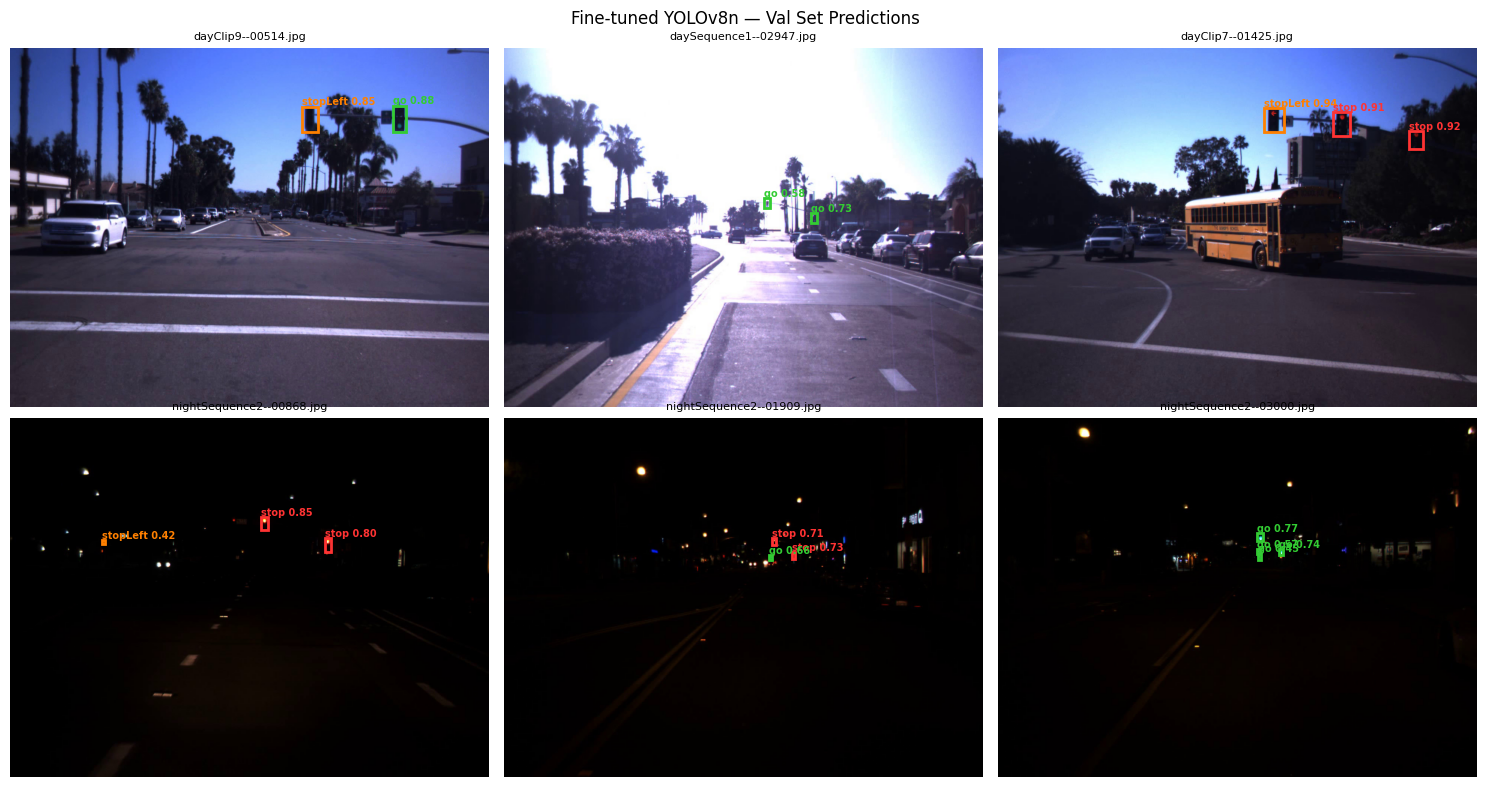

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO

infer_model = YOLO(str(dest_best))

val_imgs_list = list((YOLO_DATA / "images" / "val").glob("*.jpg"))
random.seed(1)
sample = random.sample(val_imgs_list, min(6, len(val_imgs_list)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, img_path in zip(axes.flat, sample):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    preds = infer_model.predict(img_bgr, conf=0.25, verbose=False)[0]

    ax.imshow(img_rgb)
    for box in preds.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cls_idx = int(box.cls[0])
        conf    = float(box.conf[0])
        color   = COLORS[cls_idx % len(COLORS)]
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        label = f"{CLASS_NAMES[cls_idx]} {conf:.2f}"
        ax.text(x1, y1 - 4, label, color=color, fontsize=7, fontweight="bold")

    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")

plt.suptitle("Fine-tuned YOLOv8n — Val Set Predictions", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
#  Blur license plates in test videos
# Add this after the quick validation inference cell.
# This assumes your model has a class for license plates.

import cv2
from ultralytics import YOLO
from pathlib import Path

video_model = YOLO(str(dest_best))

input_video = "/content/test_video.mp4"
output_video = "/content/test_video_blurred.mp4"

cap = cv2.VideoCapture(input_video)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

writer = cv2.VideoWriter(
    output_video,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

# Change this to the actual class name or class index used in your model
LICENSE_PLATE_CLASS_NAME = "license_plate"

while True:
    ret, frame = cap.read()
    if not ret:
        break

    result = video_model.predict(frame, conf=0.25, verbose=False)[0]

    for box in result.boxes:
        cls_idx = int(box.cls[0])
        cls_name = result.names[cls_idx]

        if cls_name == LICENSE_PLATE_CLASS_NAME:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

            # Keep coordinates inside the frame
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(frame.shape[1], x2)
            y2 = min(frame.shape[0], y2)

            roi = frame[y1:y2, x1:x2]
            if roi.size > 0:
                blurred_roi = cv2.GaussianBlur(roi, (51, 51), 0)
                frame[y1:y2, x1:x2] = blurred_roi

    writer.write(frame)

cap.release()
writer.release()

print(f"Blurred video saved to: {output_video}")

## (Optional) Resume Training from Last Checkpoint

If training was interrupted, run the cell below to continue from where it stopped.

In [ ]:
last_ckpt = Path(RUN_PROJECT) / RUN_NAME / "weights" / "last.pt"

if last_ckpt.exists():
    resume_model = YOLO(str(last_ckpt))
    results = resume_model.train(resume=True)
    print("Resumed training complete.")
else:
    print("No last.pt found at", last_ckpt)